In [2]:
# Sales Trend Analysis
Exploratory analysis of UCI Online Retail dataset (541K transactions, 2010–2011)

SyntaxError: invalid decimal literal (2647780268.py, line 2)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv('../data/online_retail.csv', encoding='latin-1')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 3 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


In [5]:
print("=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print(f"\nDate range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['CustomerID'].nunique():,.0f}")
print(f"Unique countries: {df['Country'].nunique()}")

=== NULL VALUES ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== DATA TYPES ===
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Date range: 1/10/2011 10:04 → 9/9/2011 9:52
Unique customers: 4,372
Unique countries: 38


In [6]:
# Remove missing CustomerIDs
df = df.dropna(subset=['CustomerID'])

# Remove cancellations (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove zero/negative quantities and prices
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Parse dates + create Revenue column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"Clean dataset: {df.shape[0]:,} rows")
print(f"Revenue column sample:\n{df['Revenue'].describe().round(2)}")

Clean dataset: 397,884 rows
Revenue column sample:
count    397884.00
mean         22.40
std         309.07
min           0.00
25%           4.68
50%          11.80
75%          19.80
max      168469.60
Name: Revenue, dtype: float64


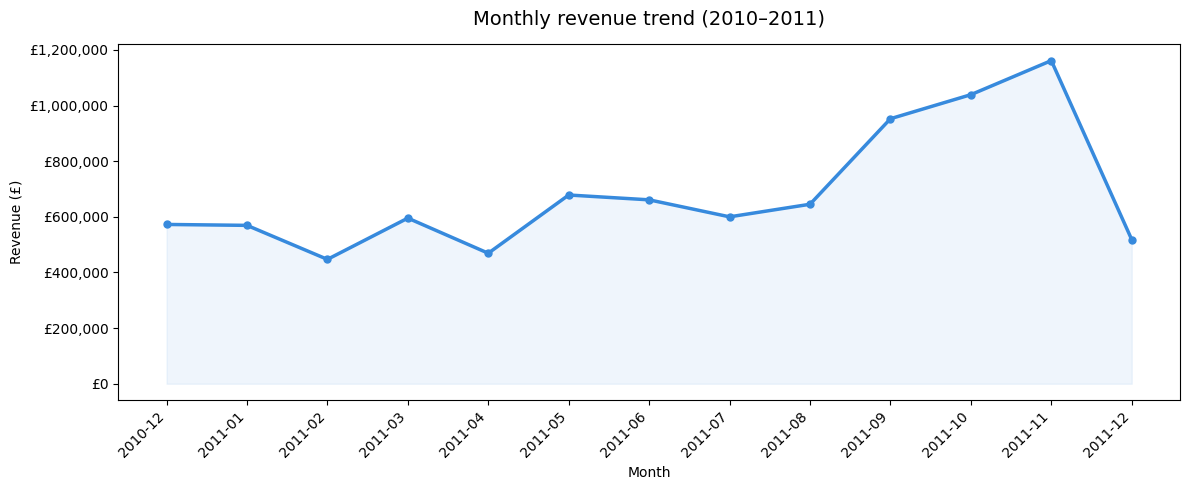

Chart saved!


In [7]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = (
    df.groupby('YearMonth')['Revenue']
    .sum()
    .reset_index()
)
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'],
        color='#378ADD', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(monthly_revenue['YearMonth'], monthly_revenue['Revenue'],
                alpha=0.08, color='#378ADD')
ax.set_title('Monthly revenue trend (2010–2011)', fontsize=14, pad=14)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/charts/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

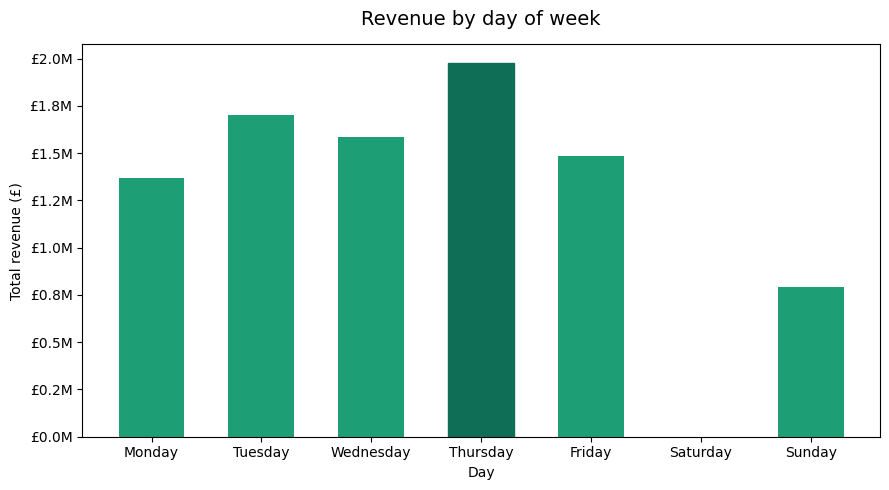

Chart saved!


In [8]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_revenue = (
    df.groupby('DayOfWeek')['Revenue']
    .sum()
    .reindex(day_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(day_revenue['DayOfWeek'], day_revenue['Revenue'],
              color='#1D9E75', edgecolor='none', width=0.6)
peak_idx = day_revenue['Revenue'].idxmax()
bars[peak_idx].set_color('#0F6E56')
ax.set_title('Revenue by day of week', fontsize=14, pad=14)
ax.set_xlabel('Day')
ax.set_ylabel('Total revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../outputs/charts/revenue_by_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

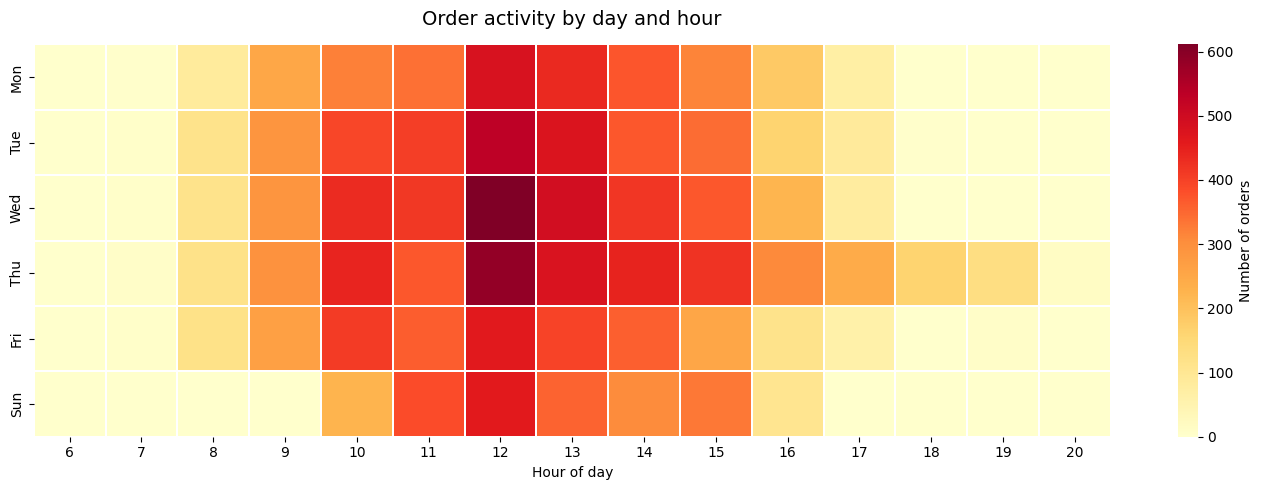

Chart saved!


In [9]:
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeekNum'] = df['InvoiceDate'].dt.dayofweek

heatmap_data = (
    df.groupby(['DayOfWeekNum', 'Hour'])['InvoiceNo']
    .nunique()
    .unstack(fill_value=0)
)

# Safe rename — only rename rows that exist
day_names = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
heatmap_data.index = [day_names[i] for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Number of orders'})
ax.set_title('Order activity by day and hour', fontsize=14, pad=14)
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../outputs/charts/order_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

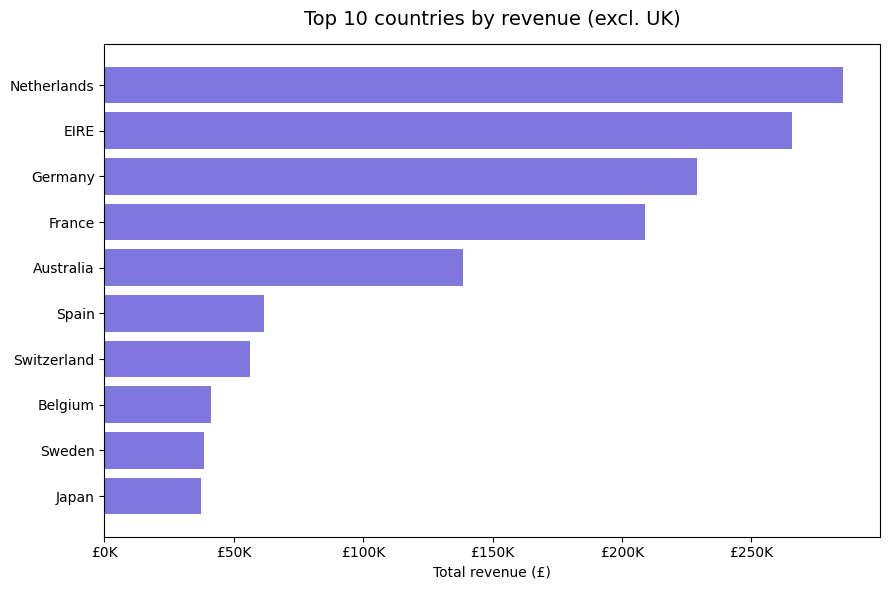

Chart saved!


In [10]:
top_countries = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_countries.index, top_countries.values,
               color='#7F77DD', edgecolor='none')
ax.set_title('Top 10 countries by revenue (excl. UK)', fontsize=14, pad=14)
ax.set_xlabel('Total revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/charts/top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [11]:
# ── Key findings summary ──────────────────────────────────
total_revenue = df['Revenue'].sum()
best_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmax()]
best_day = day_revenue.loc[day_revenue['Revenue'].idxmax()]
top_country = top_countries.index[-1]

print("=" * 50)
print("KEY FINDINGS — SALES TREND ANALYSIS")
print("=" * 50)
print(f"Total revenue:      £{total_revenue:,.0f}")
print(f"Total orders:       {df['InvoiceNo'].nunique():,}")
print(f"Total customers:    {df['CustomerID'].nunique():,}")
print(f"Best month:         {best_month['YearMonth']}  (£{best_month['Revenue']:,.0f})")
print(f"Best day:           {best_day['DayOfWeek']}")
print(f"Top country (excl UK): {top_country}")
print(f"Peak hours:         10am – 3pm on weekdays")
print("=" * 50)

KEY FINDINGS — SALES TREND ANALYSIS
Total revenue:      £8,911,408
Total orders:       18,532
Total customers:    4,338
Best month:         2011-11  (£1,161,817)
Best day:           Thursday
Top country (excl UK): Netherlands
Peak hours:         10am – 3pm on weekdays
